Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
print(sys.executable)

c:\Users\USER\AppData\Local\Programs\Python\Python314\python.exe


In [3]:
!pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
print(sns.__version__)


0.13.2


Load CSV files

In [7]:
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

Understand data

In [8]:
orders.head()
orders.info()
orders.isnull().sum()
orders.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


np.int64(0)

Merge datasets

In [9]:
df = orders.merge(items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(customers, on="customer_id", how="left")
df = df.merge(payments, on="order_id", how="left")
df = df.merge(reviews, on="order_id", how="left")

Clean data
Convert dates:

In [10]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

Create new columns:

In [11]:
df["revenue"] = df["price"] + df["freight_value"]
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M")
df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days

Prepare final dataframe

In [12]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"])

df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["revenue"] = df["price"] + df["freight_value"]

df["delivery_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

df["delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

A. Monthly revenue trend

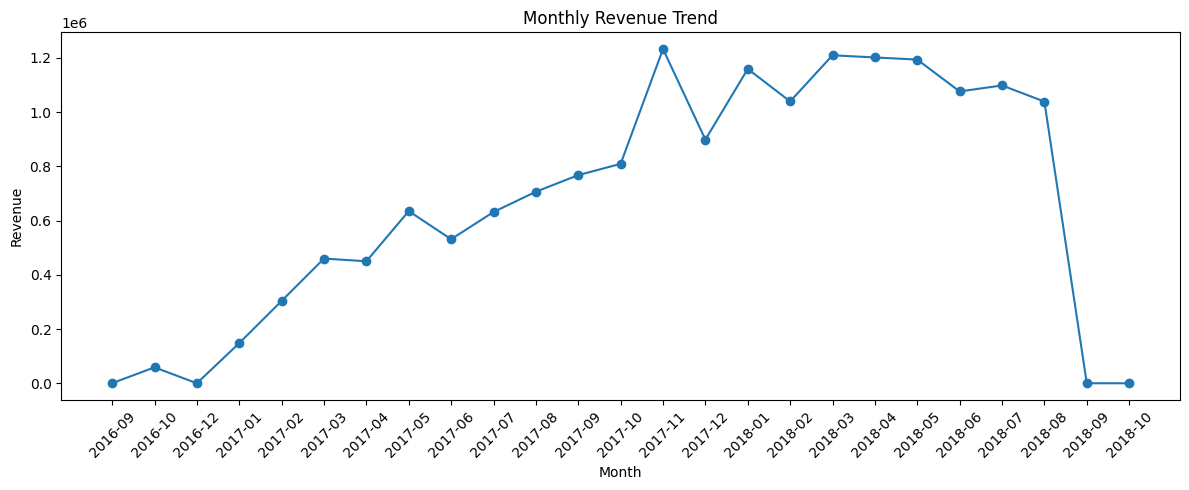

In [13]:
monthly_revenue = df.groupby("order_month")["revenue"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(monthly_revenue["order_month"], monthly_revenue["revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Revenue shows a changing monthly trend, with some months performing better than others. This suggests that the business may have seasonal sales patterns or campaign-driven demand.

B. Top product categories by revenue

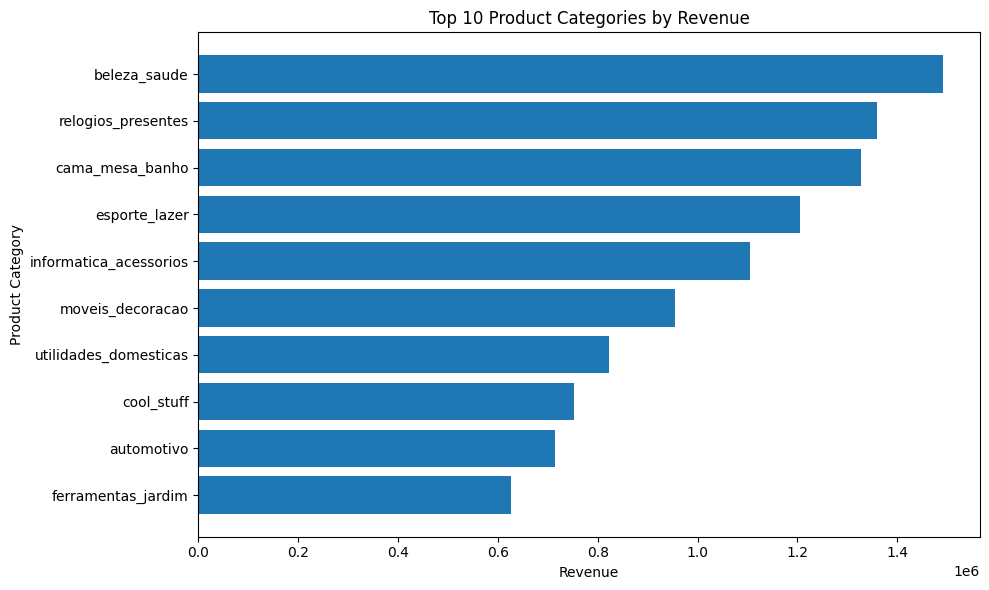

In [14]:
top_categories = (
    df.groupby("product_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
plt.barh(top_categories["product_category_name"], top_categories["revenue"])
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product Category")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

A small number of product categories generate a large portion of total revenue. These categories should be prioritized for marketing, inventory planning, and seller support.

C. Top states by customers

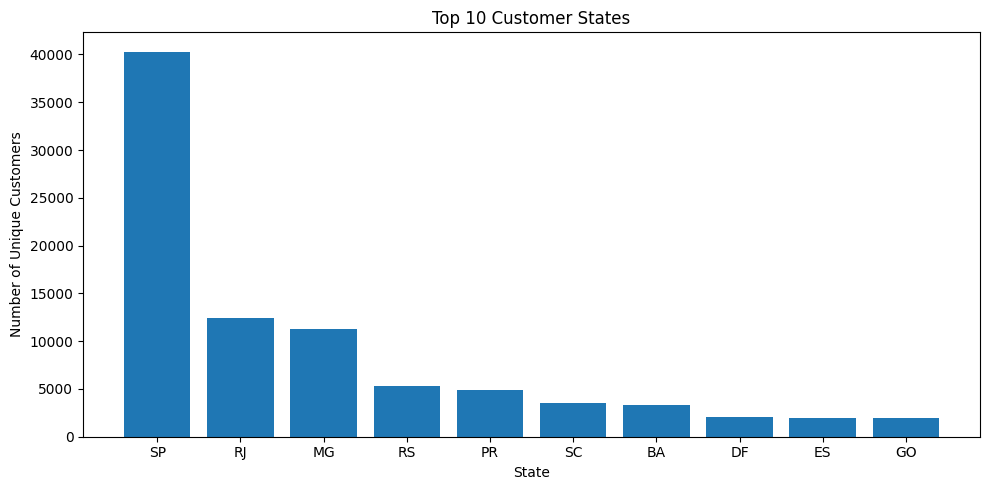

In [15]:
top_states = (
    df.groupby("customer_state")["customer_unique_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
plt.bar(top_states["customer_state"], top_states["customer_unique_id"])
plt.title("Top 10 Customer States")
plt.xlabel("State")
plt.ylabel("Number of Unique Customers")
plt.tight_layout()
plt.show()

Some states have much higher customer concentration than others. These locations are strong markets for targeted advertising and logistics improvement.

D. Most used payment methods

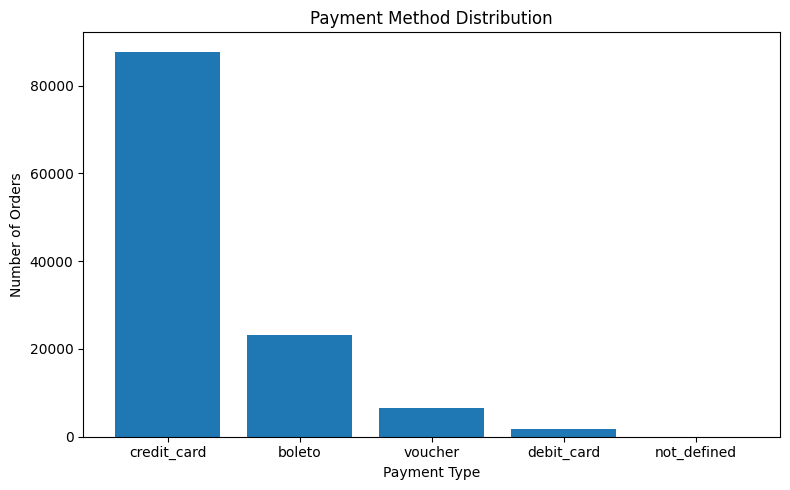

In [16]:
payment_methods = df["payment_type"].value_counts().reset_index()
payment_methods.columns = ["payment_type", "count"]

plt.figure(figsize=(8,5))
plt.bar(payment_methods["payment_type"], payment_methods["count"])
plt.title("Payment Method Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

The most used payment method shows how customers prefer to complete purchases. This can help the business improve checkout experience and payment promotions.

E. Review score distribution

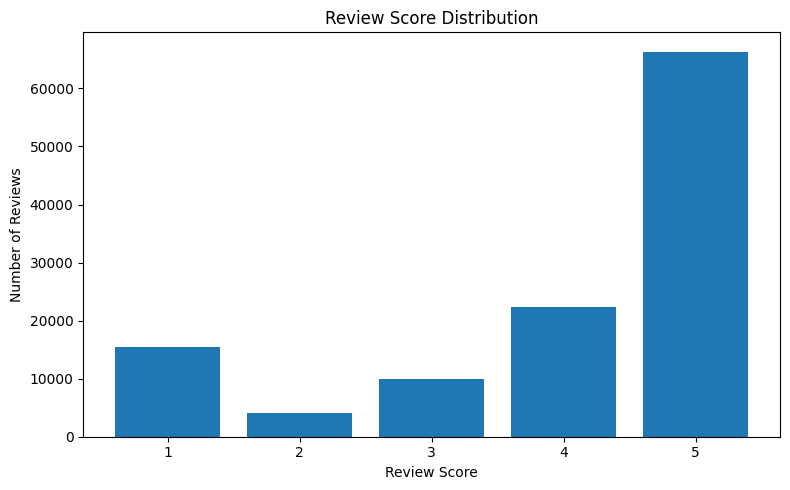

In [17]:
review_scores = df["review_score"].value_counts().sort_index().reset_index()
review_scores.columns = ["review_score", "count"]

plt.figure(figsize=(8,5))
plt.bar(review_scores["review_score"], review_scores["count"])
plt.title("Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

Most reviews are concentrated around certain score levels. Low review scores should be investigated to understand customer pain points.

F. Delivery time vs review score

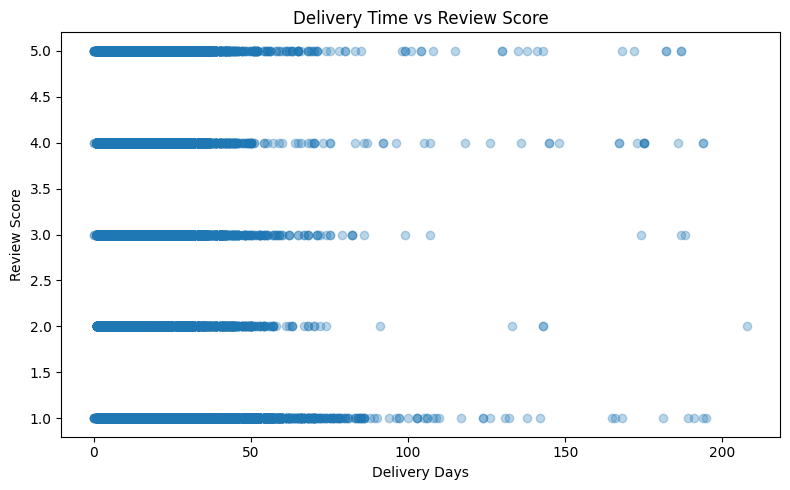

In [18]:
delivery_review = df.dropna(subset=["delivery_days", "review_score"])

plt.figure(figsize=(8,5))
plt.scatter(delivery_review["delivery_days"], delivery_review["review_score"], alpha=0.3)
plt.title("Delivery Time vs Review Score")
plt.xlabel("Delivery Days")
plt.ylabel("Review Score")
plt.tight_layout()
plt.show()

Average delivery days by score

In [19]:
avg_delivery_by_score = (
    delivery_review.groupby("review_score")["delivery_days"]
    .mean()
    .reset_index()
)

avg_delivery_by_score

,review_score,delivery_days
0,1.0,19.099992
1,2.0,15.381893
2,3.0,13.552435
3,4.0,11.778330
4,5.0,10.203253


Orders with longer delivery times may receive lower review scores. Improving delivery performance can help increase customer satisfaction.

## Business Recommendations

1. Focus marketing campaigns on the top revenue-generating product categories.
2. Improve delivery performance, especially for orders with long delivery times.
3. Target high-customer states with location-based promotions.
4. Monitor product categories and sellers connected with low review scores.
5. Improve checkout and payment experience based on the most used payment methods.